In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tips.csv")

In [50]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [52]:
df.shape

(244, 7)

In [53]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [54]:
df[df.duplicated()]

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


In [55]:
df.drop_duplicates(inplace = True)

In [56]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [57]:
df = df.rename(columns={"sex":"gender"})

In [58]:
df.groupby("gender")["tip"].sum()

gender
Female    244.51
Male      485.07
Name: tip, dtype: float64

In [59]:
df["total_bill"].mean()

19.813868312757204

In [60]:
df["gender"].value_counts()

gender
Male      157
Female     86
Name: count, dtype: int64

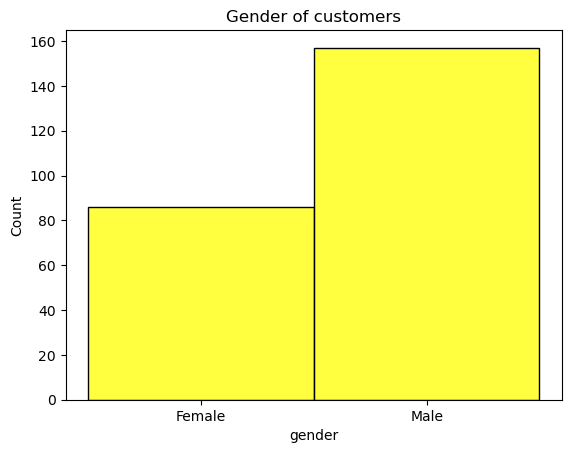

In [61]:
sns.histplot(data=df, x="gender", bins=10, color ="yellow")
plt.title("Gender of customers")
plt.show()

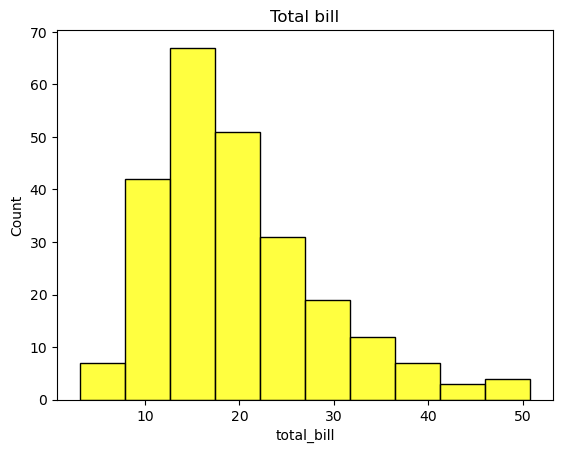

In [69]:
sns.histplot(data = df, x = "total_bill", bins = 10, color = "yellow")
plt.title("Total bill")
plt.show()

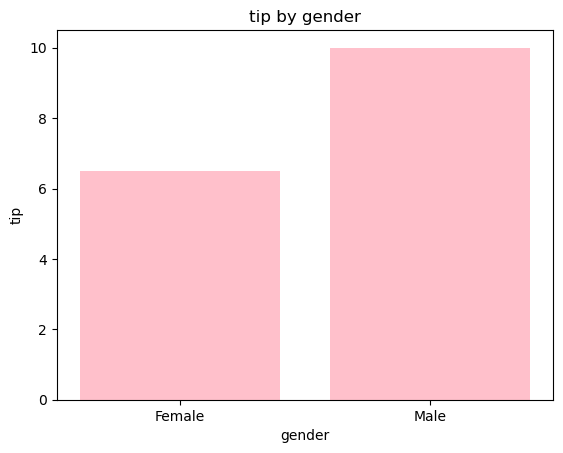

In [64]:
plt.bar(df["gender"], df["tip"], color = "pink", label = "tips.csv")
plt.xlabel("gender")
plt.ylabel("tip")
plt.title("tip by gender")
plt.show()

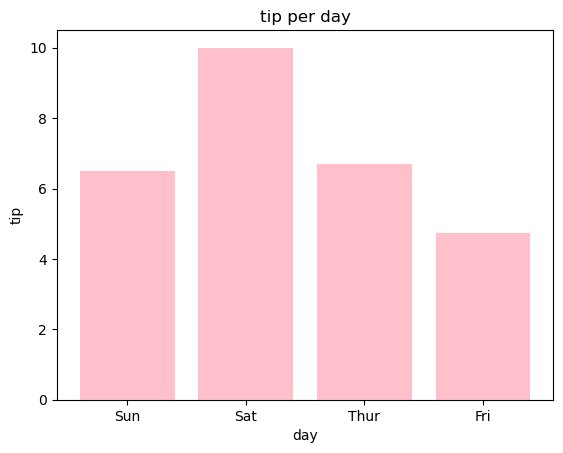

In [65]:
plt.bar(df["day"], df["tip"], color = "pink", label = "tips.csv")
plt.xlabel("day")
plt.ylabel("tip")
plt.title("tip per day")
plt.show()

limit: -0.36250000000000027 to 5.9375
Q1: 2.0  Q3: 3.575  IQR: 1.6
Number of outliers: 8


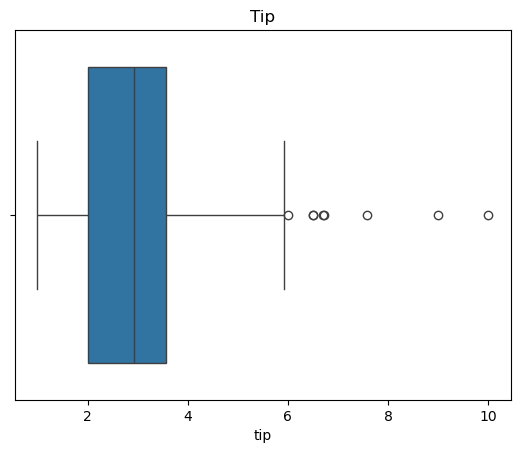

In [68]:
q1 = df["tip"].quantile(0.25)
q3 = df["tip"].quantile(0.75)
iqr = q3 - q1

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
print("limit:", low, "to", high)

print("Q1:", q1, " Q3:", q3, " IQR:", round(iqr, 1))
print("Number of outliers:", len(outliers))
outliers.sort_values("tip", ascending=False).head()
sns.boxplot(data=df, x="tip")
plt.title("Tip")
plt.show()

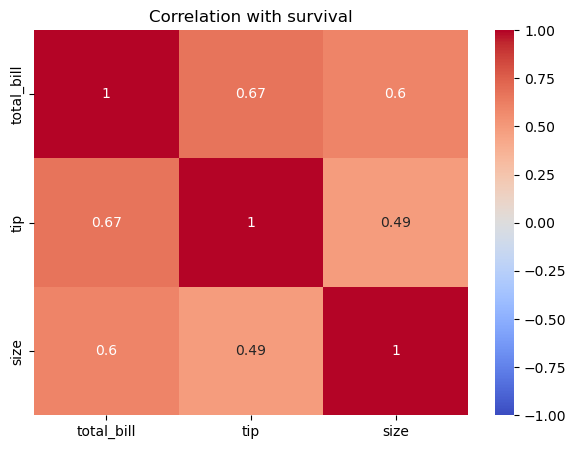

In [78]:
cols = ["total_bill", "tip","size"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr().round(2), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with survival")
plt.show()